# Setup (Imports and Preparations)

In [73]:
import os
import ast

import matplotlib.pyplot as plt	
import matplotlib.patches as patches

# Custom Library
import ActivationPrototypes_SARSeg.thesis_utils as utils
from ActivationPrototypes_SARSeg.thesis_utils import *

In [151]:
from importlib import reload
reload(utils)
from ActivationPrototypes_SARSeg.thesis_utils import *

In [168]:
dataset_lmdb_path = '../data/Encoded-BigEarthNet'
parquet_path = '../data/metadata.parquet'
prototype_lmdb_path = "../data/prototypes_subsample"

device = 'cuda' if torch.cuda.is_available() else 'cpu'
layer_names = ["encoder.layer3", "encoder.layer4", "decoder.up1", "decoder.up2"]

IMG_SIZE = (120,120)
IMG_HEIGHT = 120
IMG_WIDTH  = 120
IMG_CHANNELS = 2

model = load_from_checkpoint_skipconn("../models/unet120_full_skipconn_best.pth")  # Modify this with your actual model loading function
model.eval()
model.to(device);

CustomUnet initialized with encoder channels: (2, 64, 256, 512, 1024, 2048)


In [9]:
train_matches, val_matches, test_matches = match_keys(parquet_path)

random.seed(42)
train_matches_subsample = random.sample(train_matches, len(train_matches)//10)

subsample_image_keys = []
subsample_mask_keys = []
# for match in old_train_matches:
for match in train_matches_subsample:
    train_image_key, train_mask_key = match
    subsample_image_keys.append(train_image_key)
    subsample_mask_keys.append(train_mask_key)

print(train_matches_subsample[:5])

[('S1A_IW_GRDH_1SDV_20180126T161302_34VDN_15_88', 'S2B_MSIL2A_20180127T102259_N9999_R065_T34VDN_15_88_reference_map'), ('S1A_IW_GRDH_1SDV_20170903T153258_35VNL_70_4', 'S2A_MSIL2A_20170905T095031_N9999_R079_T35VNL_70_04_reference_map'), ('S1A_IW_GRDH_1SDV_20170617T064659_29UPU_62_3', 'S2A_MSIL2A_20170617T113321_N9999_R080_T29UPU_62_03_reference_map'), ('S1A_IW_GRDH_1SDV_20180420T063917_29UPU_27_80', 'S2B_MSIL2A_20180421T114349_N9999_R123_T29UPU_27_80_reference_map'), ('S1A_IW_GRDH_1SDV_20180413T161957_34UEG_40_3', 'S2A_MSIL2A_20180413T095031_N9999_R079_T34UEG_40_03_reference_map')]


In [10]:
regions = {
    # First Row
    "A": (0, 0, IMG_WIDTH/4 , IMG_HEIGHT/4),
    "B": (IMG_WIDTH/4, 0, IMG_WIDTH/2, IMG_HEIGHT/4),
    "C": (IMG_WIDTH/2, 0, 3*IMG_WIDTH/4, IMG_HEIGHT/4),
    "D": (3*IMG_WIDTH/4, 0, IMG_WIDTH, IMG_HEIGHT/4),
    # Second Row
    "E": (0, IMG_HEIGHT/4, IMG_WIDTH/4, IMG_HEIGHT/2),
    "F": (IMG_WIDTH/4, IMG_HEIGHT/4, IMG_WIDTH/2, IMG_HEIGHT/2),
    "G": (IMG_WIDTH/2, IMG_HEIGHT/4, 3*IMG_WIDTH/4, IMG_HEIGHT/2),
    "H": (3*IMG_WIDTH/4, IMG_HEIGHT/4, IMG_WIDTH, IMG_HEIGHT/2),
    # Third Row
    "I": (0, IMG_HEIGHT/2, IMG_WIDTH/4, 3*IMG_HEIGHT/4),
    "J": (IMG_WIDTH/4, IMG_HEIGHT/2, IMG_WIDTH/2, 3*IMG_HEIGHT/4),
    "K": (IMG_WIDTH/2, IMG_HEIGHT/2, 3*IMG_WIDTH/4, 3*IMG_HEIGHT/4),
    "L": (3*IMG_WIDTH/4, IMG_HEIGHT/2, IMG_WIDTH, 3*IMG_HEIGHT/4),
    # Fourth Row
    "M": (0, 3*IMG_HEIGHT/4, IMG_WIDTH/4, IMG_HEIGHT),
    "N": (IMG_WIDTH/4, 3*IMG_HEIGHT/4, IMG_WIDTH/2, IMG_HEIGHT),
    "O": (IMG_WIDTH/2, 3*IMG_HEIGHT/4, 3*IMG_WIDTH/4, IMG_HEIGHT),
    "P": (3*IMG_WIDTH/4, 3*IMG_HEIGHT/4, IMG_WIDTH, IMG_HEIGHT),
}

In [35]:
random.seed(42)
num = 1000
random_regions = random.choices(list(regions.values()), k=num)
random_references = random.sample(test_matches, num)
random_test_imgs, random_test_masks = [], []

print(f"Random references: {random_references}")
for image_reference, mask_reference in random_references:
    test_img, test_mask = get_image_and_mask_from_key(image_reference, mask_reference, lmdb_path = dataset_lmdb_path)
    random_test_imgs.append(test_img)
    random_test_masks.append(test_mask)

# Validate correct loading
for i in range(5):
    temp_img = random_test_imgs[i]	
    temp_mask = random_test_masks[i]	

    temp_image_mask_tuple = random_references[i]	
    temp_compare_img, temp_compare_mask = get_image_and_mask_from_key(temp_image_mask_tuple[0], temp_image_mask_tuple[1], lmdb_path = dataset_lmdb_path)	
    
    print(np.array_equal(temp_img, temp_compare_img))
    print(np.array_equal(temp_mask, temp_compare_mask))		

Random references: [('S1A_IW_GRDH_1SDV_20170812T182647_29SNC_25_55', 'S2A_MSIL2A_20170813T112121_N9999_R037_T29SNC_25_55_reference_map'), ('S1B_IW_GRDH_1SDV_20180225T064227_29SNC_33_48', 'S2B_MSIL2A_20180224T112109_N9999_R037_T29SNC_33_48_reference_map'), ('S1A_IW_GRDH_1SDV_20180511T043205_35WPP_26_54', 'S2A_MSIL2A_20180510T094031_N9999_R036_T35WPP_26_54_reference_map'), ('S1A_IW_GRDH_1SDV_20170925T043256_35VPK_44_42', 'S2B_MSIL2A_20170924T093019_N9999_R136_T35VPK_44_42_reference_map'), ('S1B_IW_GRDH_1SDV_20180524T154016_35VNL_33_37', 'S2B_MSIL2A_20180525T094029_N9999_R036_T35VNL_33_37_reference_map'), ('S1B_IW_GRDH_1SDV_20171220T050937_33TWN_63_66', 'S2B_MSIL2A_20171219T095409_N9999_R079_T33TWN_63_66_reference_map'), ('S1A_IW_GRDH_1SDV_20180509T160543_34VDR_64_67', 'S2A_MSIL2A_20180509T101031_N9999_R022_T34VDR_64_67_reference_map'), ('S1A_IW_GRDH_1SDV_20170706T064300_29SND_42_61', 'S2A_MSIL2A_20170704T112111_N9999_R037_T29SND_42_61_reference_map'), ('S1B_IW_GRDH_1SDV_20170709T043159_3

In [150]:
from torch.utils.data import DataLoader
import albumentations as A

transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
],is_check_shapes=False)

print(f"Train size: {len(train_matches)}, Val size: {len(val_matches)}, Test size: {len(test_matches)}")

# Create datasets	
train_dataset = SARSegmentationDataset120(dataset_lmdb_path, train_matches[:], transform=transform)
val_dataset = SARSegmentationDataset120(dataset_lmdb_path, val_matches[:], transform=None)
test_dataset = SARSegmentationDataset120(dataset_lmdb_path, test_matches[:], transform=None)

# Create data loaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Train size: 237871, Val size: 122342, Test size: 119825
Opening LMDB environment ...
Opening LMDB environment ...
Opening LMDB environment ...


# Analyze Top N Matches

In [53]:
if os.path.exists("top_matches_skipp_conn.csv"):
    data_matches = pd.read_csv("top_matches_skipp_conn.csv").to_dict(orient='records')
else:
    data_matches = []

df_top_matches = pd.DataFrame(data_matches)
unique_image_ids = df_top_matches['image_id'].unique()
print(f"Unique image IDs: {unique_image_ids}")

image_top50s = {
    # "image_id": {
    #     "original_region: []",
    #     "encoder.layer3": [],
    #     "encoder.layer4": [],
    #     "decoder.up1": [],
    #     "decoder.up2": []
    # }
}

for image_id in unique_image_ids:
    image_top50s[image_id] = {
        "original_region" : (),
        "encoder.layer3": [],
        "encoder.layer4": [],
        "decoder.up1": [],
        "decoder.up2": [],
        "all_layers": []
    }
    image_top50s[image_id]["original_region"] = df_top_matches[df_top_matches['image_id'] == image_id]['original_region'].values[0]

    for layer_name in layer_names:
        top_n_values = df_top_matches[
            (df_top_matches['image_id'] == image_id) & (df_top_matches['layer'] == layer_name)]['top_n'].values[0]
        print(f"Top N values for {image_id} in {layer_name}: {top_n_values}")
        image_top50s[image_id][layer_name] = eval(str(top_n_values))
        print(f"Type of {layer_name}: {type(image_top50s[image_id][layer_name])}")

        print(type(image_top50s[image_id][layer_name]))
        #print(len(image_top50s[image_id][layer_name]))
        
    image_top50s[image_id]["all_layers"] = [ image_top50s[image_id][layer_name] for layer_name in layer_names]

Unique image IDs: ['S1A_IW_GRDH_1SDV_20170812T182647_29SNC_25_55'
 'S1B_IW_GRDH_1SDV_20180225T064227_29SNC_33_48'
 'S1A_IW_GRDH_1SDV_20180511T043205_35WPP_26_54'
 'S1A_IW_GRDH_1SDV_20170925T043256_35VPK_44_42'
 'S1B_IW_GRDH_1SDV_20180524T154016_35VNL_33_37'
 'S1B_IW_GRDH_1SDV_20171220T050937_33TWN_63_66'
 'S1A_IW_GRDH_1SDV_20180509T160543_34VDR_64_67'
 'S1A_IW_GRDH_1SDV_20170706T064300_29SND_42_61'
 'S1B_IW_GRDH_1SDV_20170709T043159_35VNL_41_32'
 'S1A_IW_GRDH_1SDV_20180202T044945_35VLJ_44_53'
 'S1A_IW_GRDH_1SDV_20171004T183515_29SNC_67_23'
 'S1A_IW_GRDH_1SDV_20170819T053446_32TMT_45_51'
 'S1A_IW_GRDH_1SDV_20180521T044858_34WFS_29_32'
 'S1B_IW_GRDH_1SDV_20180515T063421_29SNC_52_52'
 'S1A_IW_GRDH_1SDV_20170830T160543_34VDR_65_65'
 'S1A_IW_GRDH_1SDV_20170802T163325_34TCR_49_60'
 'S1A_IW_GRDH_1SDV_20180204T043318_35VNJ_24_64'
 'S1B_IW_GRDH_1SDV_20171101T042417_35VNK_65_62'
 'S1B_IW_GRDH_1SDV_20171220T050937_33TWN_50_58'
 'S1B_IW_GRDH_1SDV_20171220T050912_33TWN_39_36'
 'S1B_IW_GRDH_1SDV_201

## Overlap between Top 5, 10, 20, 50 of pairwise layers (symmetrical)

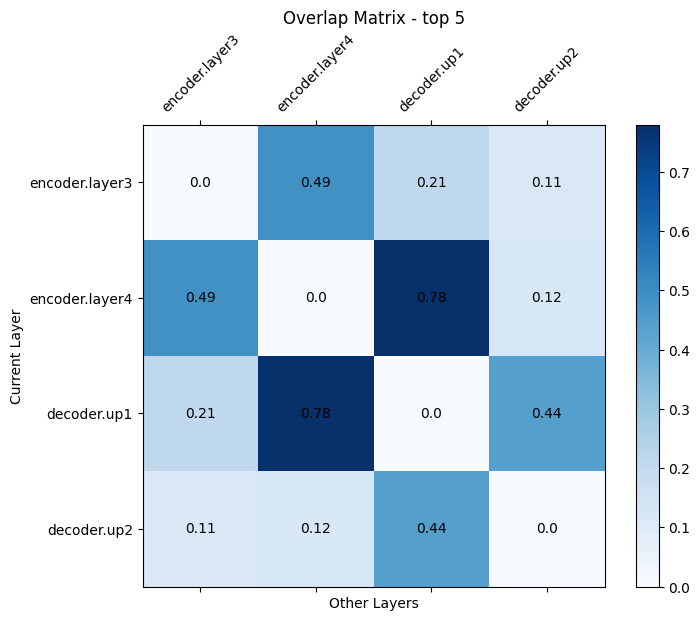

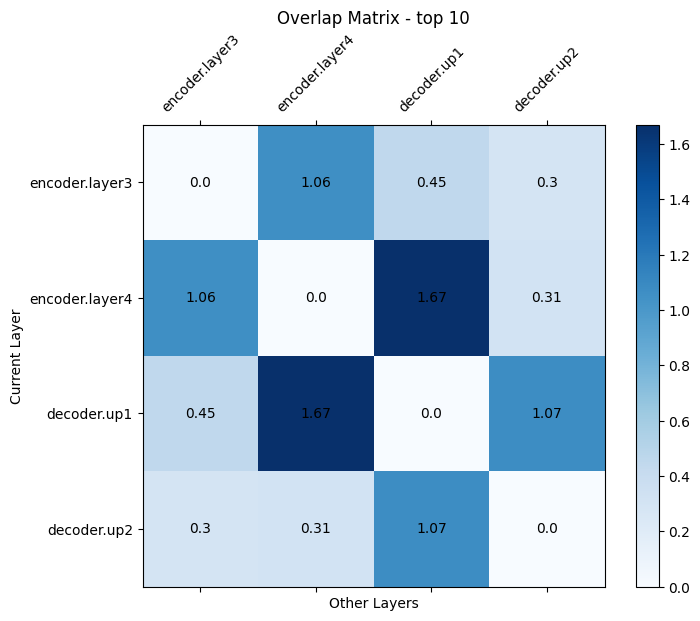

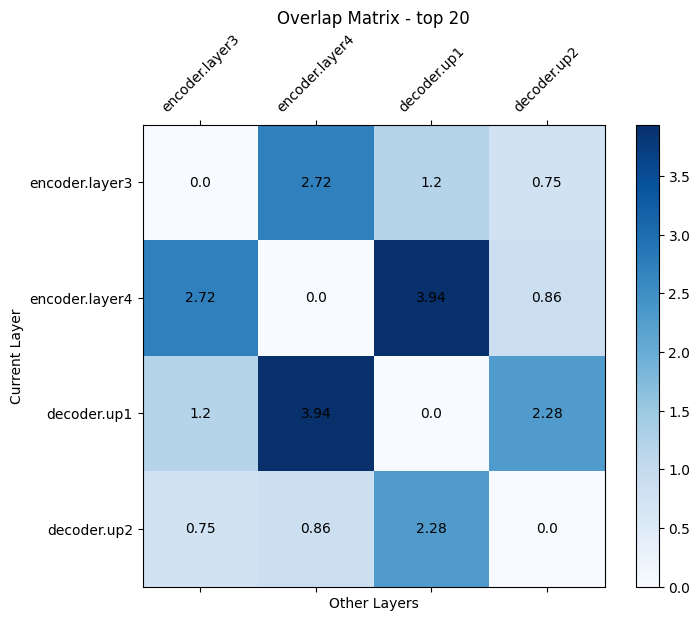

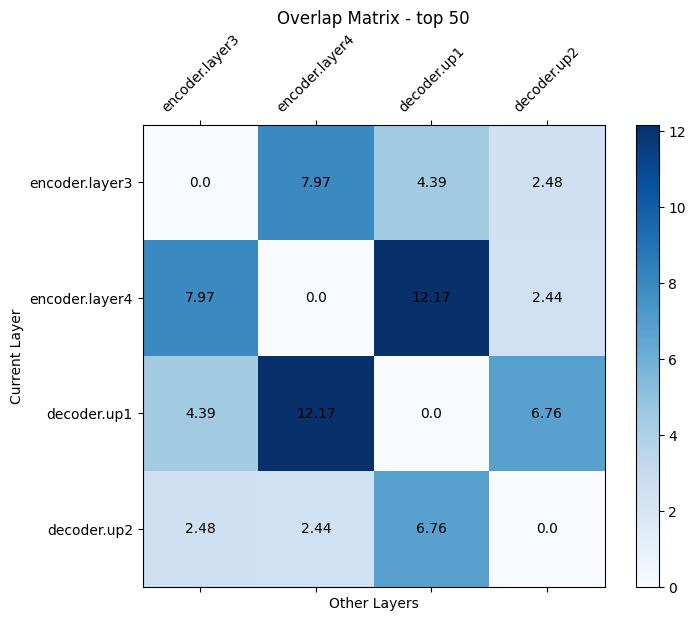

In [17]:
targets = ["top 5", "top 10", "top 20", "top 50"]
aggreated_overlaps_x = get_aggregate_overlaps([image_top50s[unique_image_ids[x]]["all_layers"] for x in range(len(unique_image_ids))], 
                                                layer_names, eta = 0.8)
show_overlap_matrix(aggreated_overlaps_x, targets, layer_names)

## Pairwise overlap of Top 5 of Layer A and Top 50 of Layer B (asymmetrical)

In [58]:
print("PyTorch Version:", torch.__version__)
print("CUDA Used By PyTorch:", torch.version.cuda)

PyTorch Version: 2.6.0+cu118
CUDA Used By PyTorch: 11.8


# Quantitative - Correctness

In [216]:
from importlib import reload
reload(utils)
from ActivationPrototypes_SARSeg.thesis_utils import *

**Description**: <br>
Faithfulness of the explanation with respect to predictive model f ,
the model to be explained. indicates how truthful the explanations are compared
to the “true” black box behavior <br>

**Metric**: <br>
Agreement between pixel values on the segmentation masks query and
prototyp <br>

**Process** <br>
1) 100 random test images with randomize region (a quadrant of the 4x4 split) and randomized layer
2) Calculate Top-10 Prototypes
3) Layer-wise IoU analysis between segmentation mask of each prototype and the query region

Random 100 images: [('S1A_IW_GRDH_1SDV_20170812T182647_29SNC_25_55', 'S2A_MSIL2A_20170813T112121_N9999_R037_T29SNC_25_55_reference_map'), ('S1B_IW_GRDH_1SDV_20180225T064227_29SNC_33_48', 'S2B_MSIL2A_20180224T112109_N9999_R037_T29SNC_33_48_reference_map'), ('S1A_IW_GRDH_1SDV_20180511T043205_35WPP_26_54', 'S2A_MSIL2A_20180510T094031_N9999_R036_T35WPP_26_54_reference_map'), ('S1A_IW_GRDH_1SDV_20170925T043256_35VPK_44_42', 'S2B_MSIL2A_20170924T093019_N9999_R136_T35VPK_44_42_reference_map'), ('S1B_IW_GRDH_1SDV_20180524T154016_35VNL_33_37', 'S2B_MSIL2A_20180525T094029_N9999_R036_T35VNL_33_37_reference_map')]
Random 100 image references: [('S1A_IW_GRDH_1SDV_20170812T182647_29SNC_25_55', 'S2A_MSIL2A_20170813T112121_N9999_R037_T29SNC_25_55_reference_map'), ('S1B_IW_GRDH_1SDV_20180225T064227_29SNC_33_48', 'S2B_MSIL2A_20180224T112109_N9999_R037_T29SNC_33_48_reference_map'), ('S1A_IW_GRDH_1SDV_20180511T043205_35WPP_26_54', 'S2A_MSIL2A_20180510T094031_N9999_R036_T35WPP_26_54_reference_map'), ('S1A_

f:\Thesis\.conda\lib\site-packages\torch\nn\modules\module.py:1739: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


Prototype [0,1] contains unique classes: [10]
Prototype [0,2] contains unique classes: [10]
Prototype [0,3] contains unique classes: [10]
Prototype [0,4] contains unique classes: [ 9 14]
Prototype [0,5] contains unique classes: [10]
Prototype [1,1] contains unique classes: [14]
Prototype [1,2] contains unique classes: [ 9 14]
Prototype [1,3] contains unique classes: [ 9 14]
Prototype [1,4] contains unique classes: [14]
Prototype [1,5] contains unique classes: [ 9 14]
Prototype [2,1] contains unique classes: [14]
Prototype [2,2] contains unique classes: [ 9 14]
Prototype [2,3] contains unique classes: [ 9 14]
Prototype [2,4] contains unique classes: [14]
Prototype [2,5] contains unique classes: [14]
Prototype [3,1] contains unique classes: [ 9 14]
Prototype [3,2] contains unique classes: [ 9 14]
Prototype [3,3] contains unique classes: [9]
Prototype [3,4] contains unique classes: [9]
Prototype [3,5] contains unique classes: [ 9 14]


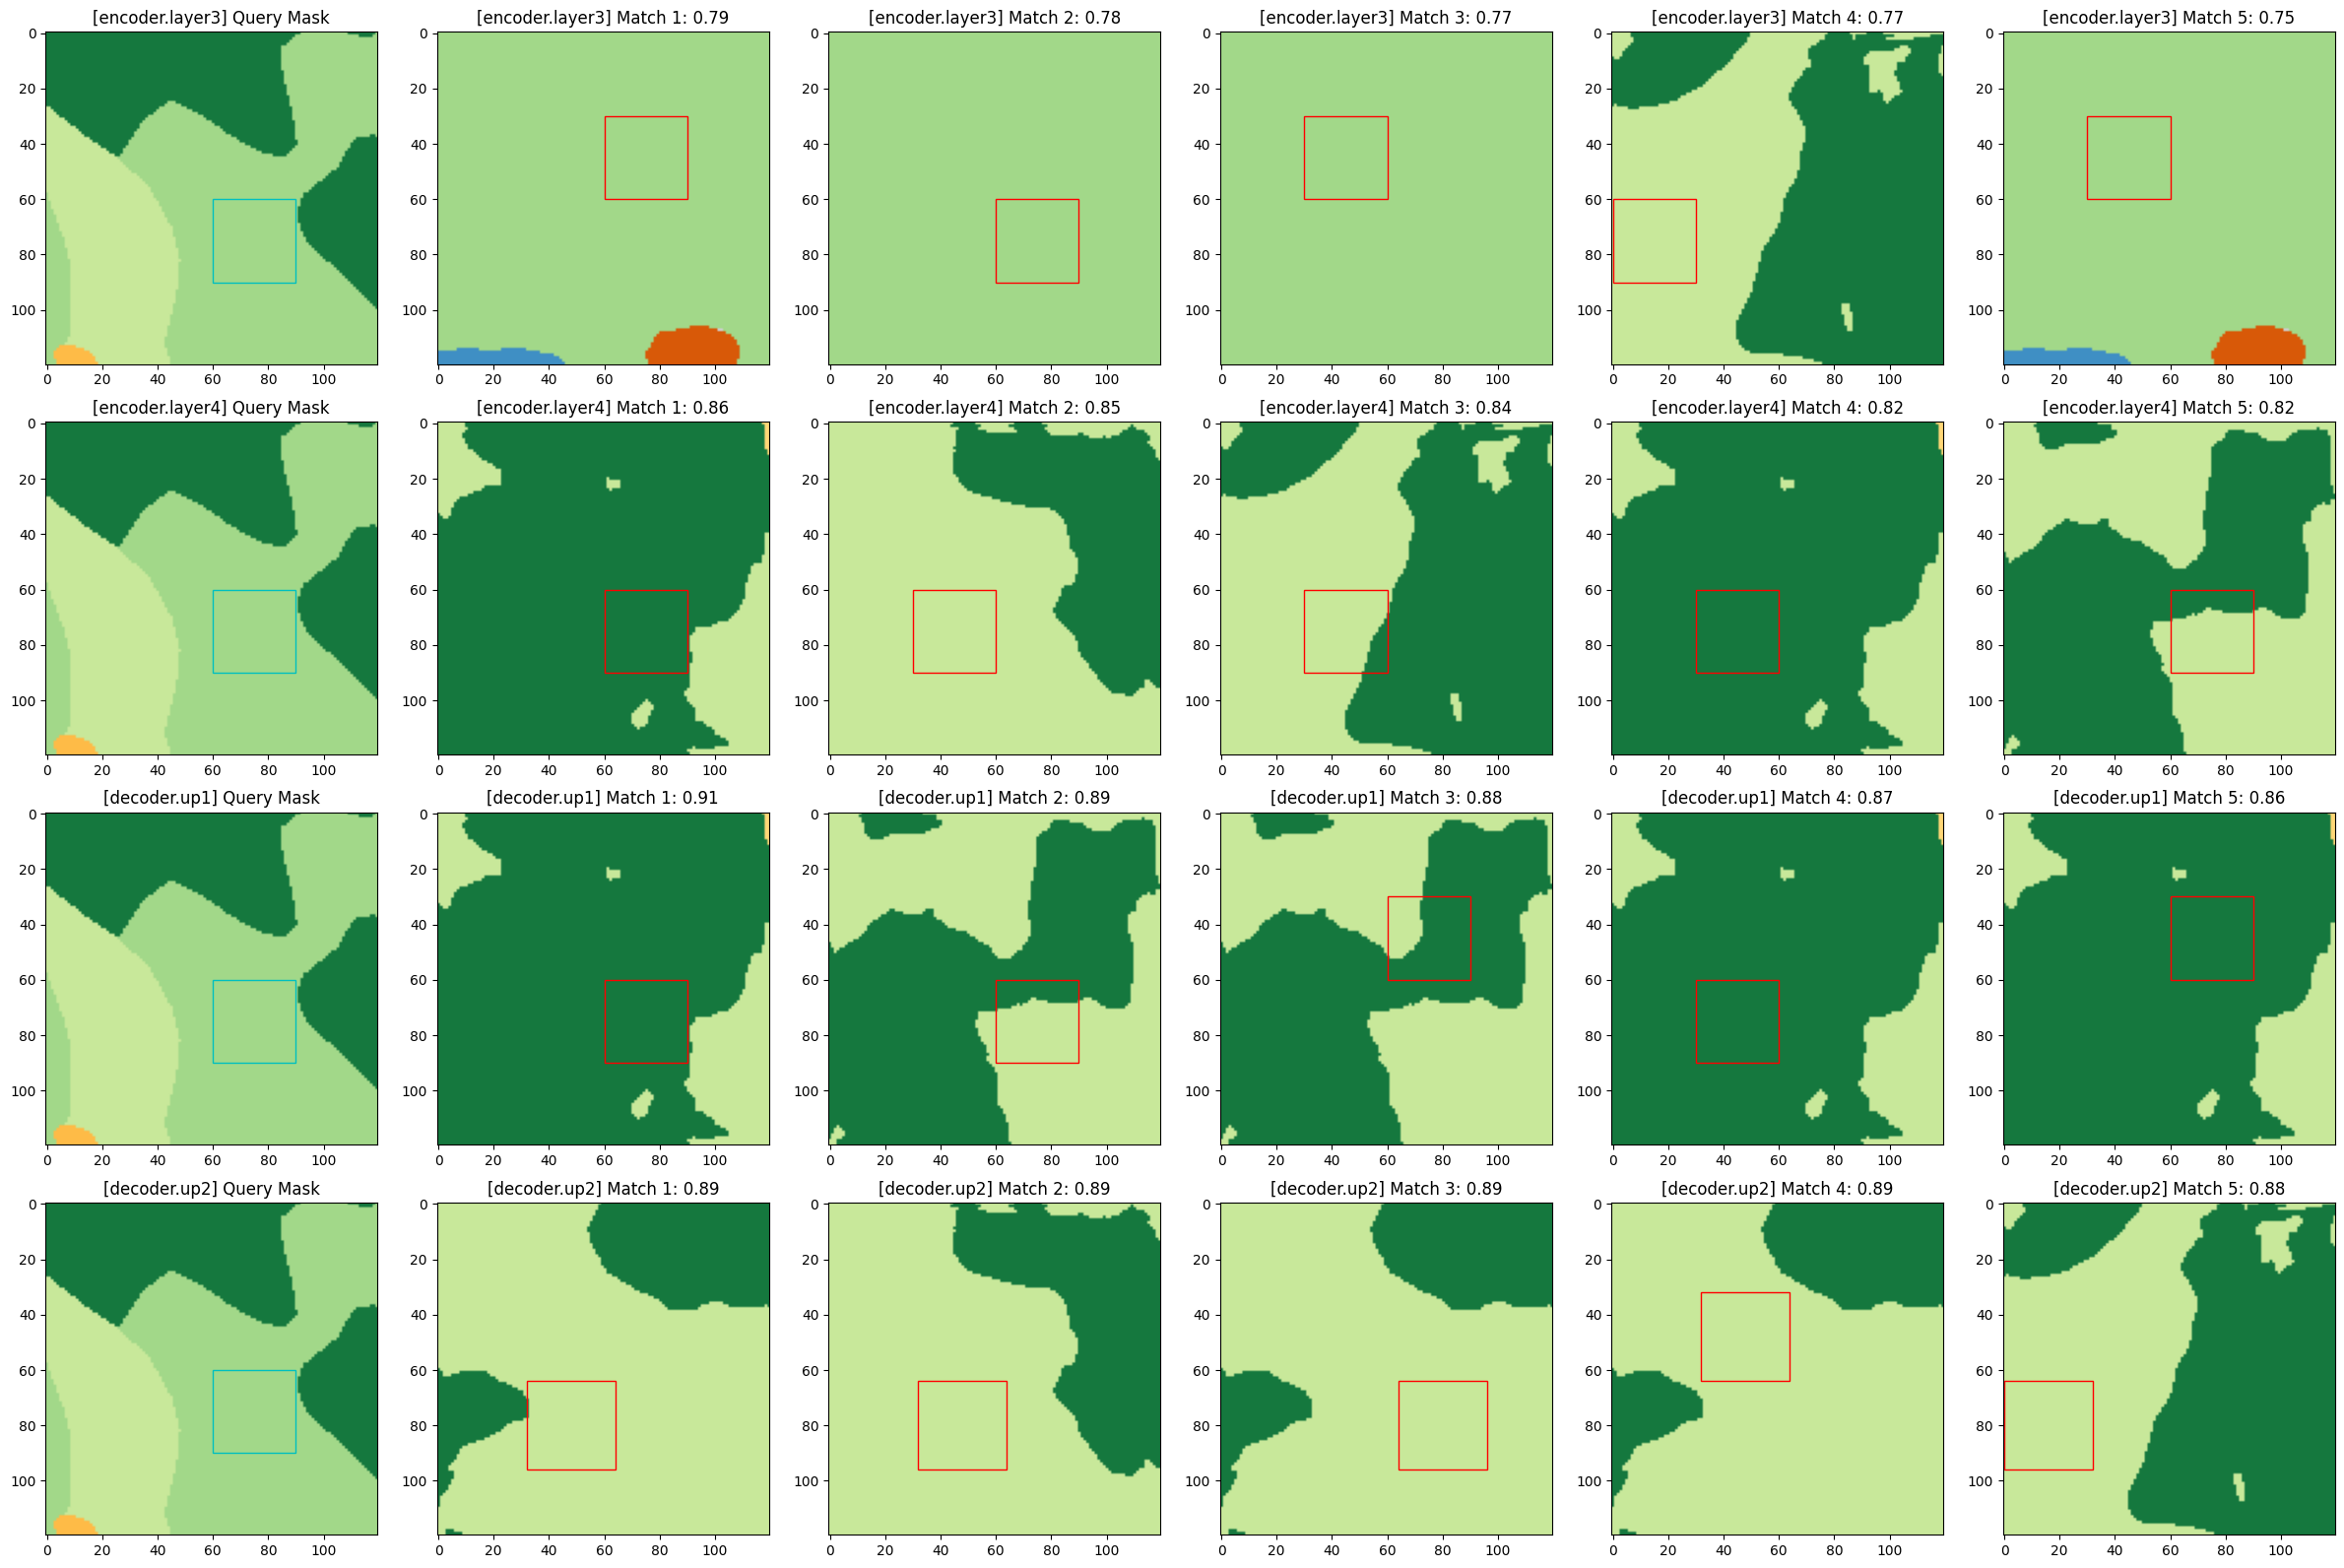

Processing query S1B_IW_GRDH_1SDV_20180225T064227_29SNC_33_48 with region (0, 0, 30.0, 30.0)

Query region contains unique classes: [10 14]


KeyboardInterrupt: 

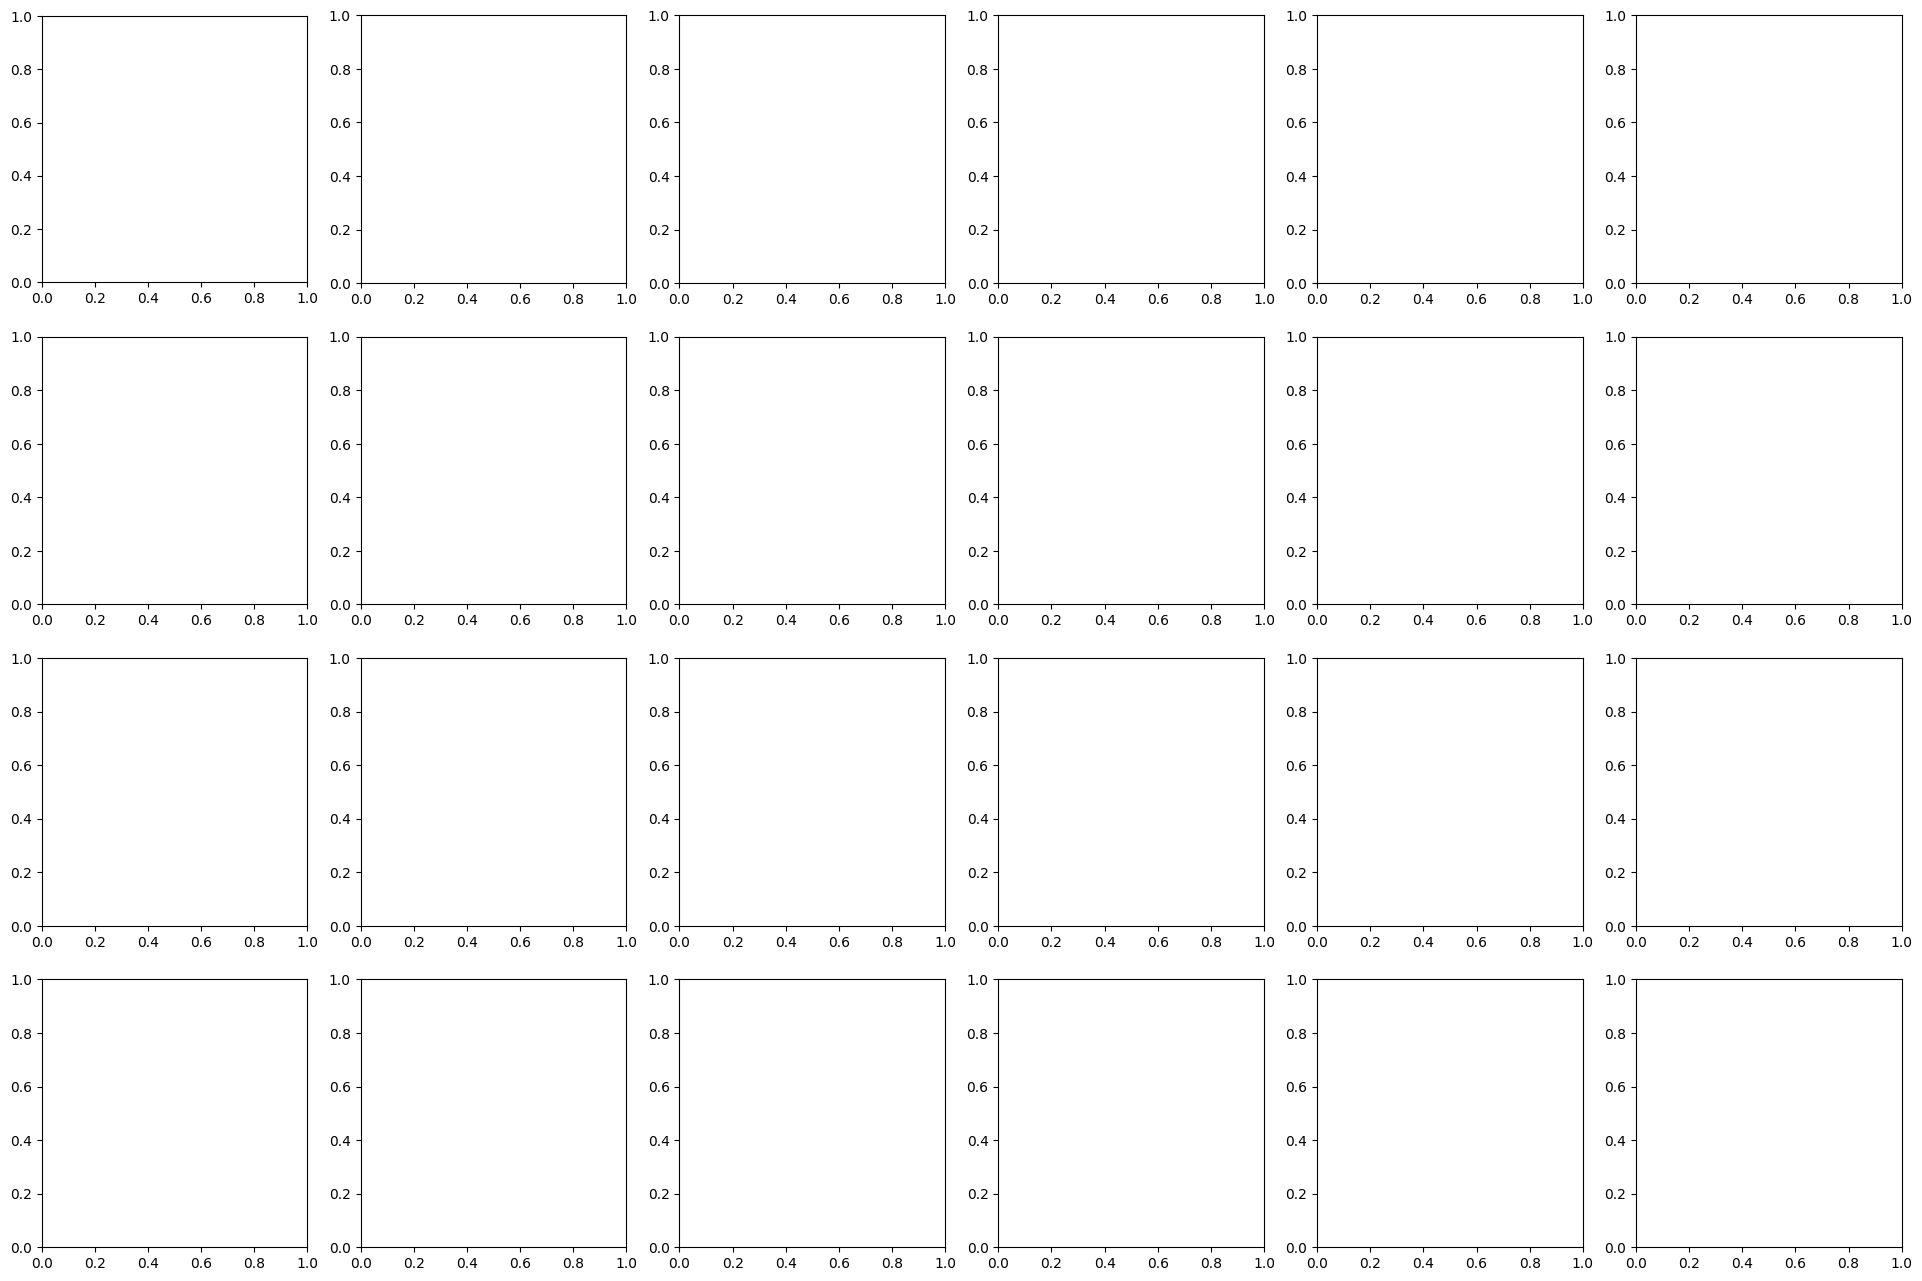

In [222]:
# 1) 100 random test images with randomized region

top_x = 5  # Select how many of the top_n matches you want

random_100_references = random_references[:100]
print(f"Random 100 images: {random_100_references[:5]}")	
random_100_images, random_100_masks = random_test_imgs[:100], random_test_masks[:100]
print(f"Random 100 image references: {random_100_references[:5]}")	
random_100_regions = random_regions[:100]	
print(f"Random 100 regions: {random_100_regions[:5]}")	

# 2) Extract top-50 from stored csv
if os.path.exists("top_matches_skipp_conn.csv"):
    data_matches = pd.read_csv("top_matches_skipp_conn.csv").to_dict(orient='records')
else:
    data_matches = []

df_top_matches = pd.DataFrame(data_matches)
df_top_matches['original_region'] =  df_top_matches['original_region'].apply(ast.literal_eval)
unique_image_ids = df_top_matches['image_id'].unique()

# Validate that all random_100_references are in the dataframe of pre-calculated results
for random_img_red, random_mask_ref in random_100_references:
    if random_img_red not in unique_image_ids:
        print(f"Image reference {random_img_red} not found in dataframe")
    else:
        continue

# Extract references from the dataframe
top_n = {}
for (image_ref, mask_ref), region in zip(random_100_references,random_100_regions):
    top_n[image_ref] = {}
    for layer_name in layer_names:
        filtered = df_top_matches[
            (df_top_matches['image_id'] == image_ref) &
            (df_top_matches['original_region'] == region) &
            (df_top_matches['layer'] == layer_name)
        ]
        if not filtered.empty:
            top_n_values = eval(str(filtered['top_n'].values[0]))[:top_x]
        else:
            print(f"No matches found for {image_ref}, {region}, {layer_name}")

        # print(f"Top N values for {image_ref} in {layer_name}: {top_n_values}")	
        top_n[image_ref][layer_name] = top_n_values


print(f"[DEBUG: Top N values for references {random_100_references[0][0]}: {top_n[random_100_references[0][0]]}\n")			

# 3) Layer-wise IoU analysis between segmentation mask of each prototype and query region
for (image_ref, mask_ref), region in zip(random_100_references, random_100_regions):
    # Load query data
    img, mask = get_image_and_mask_from_key(image_ref, mask_ref, lmdb_path=dataset_lmdb_path)
    mask_replaced_vals = replace_pixel_values_with_class_indices(mask)
    mask_colored = apply_color_map(mask_replaced_vals)

    x1, y1, x2, y2 = map(int, region)
    print(f"Processing query {image_ref} with region {region}\n")

    unique_classes_query = np.unique(mask_replaced_vals[x1:x2, y1:y2])		
    print(f"Query region contains unique classes: {unique_classes_query}")			
    # Gather matches for all layers
    layer_matches_list = []
    for layer_name in layer_names:
        matches = top_n[image_ref][layer_name]
        layer_matches_list.append(matches)

    # Determine max number of matches
    max_matches = max(len(matches) for matches in layer_matches_list) if layer_matches_list else 0

    # Create a single figure for all layers
    fig, axes = plt.subplots(
        nrows=len(layer_names),
        ncols=max_matches + 1,
        figsize=(4*(max_matches + 1), 4*len(layer_names))
    )

    # If there's only one layer, axes is 1D; make it 2D for consistent indexing
    if len(layer_names) == 1:
        axes = [axes]

    for row_idx, layer_name in enumerate(layer_names):
       # print(f"Layer: {layer_name}")
        matches = layer_matches_list[row_idx]

        # Left side: query mask with region highlight
        rect_original = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, 
                                          linewidth=1, edgecolor='c', facecolor='none')
        axes[row_idx][0].imshow(mask_colored)
        axes[row_idx][0].add_patch(rect_original)
        axes[row_idx][0].set_title(f"[{layer_name}] Query Mask")

        # Plot each prototype match in the next columns
        for col_idx, match in enumerate(matches, start=1):
            match_score, match_ref, match_region = match
            px1, py1, px2, py2 = map(int, match_region)

            # print(f"prototype region: {px1}, {py1}, {px2}, {py2}")
            match_img, _ = get_image_and_mask_from_key(match_ref, lmdb_path=dataset_lmdb_path)
            match_mask = inference(match_img, model).squeeze(0).cpu()	
            match_mask_colored = apply_color_map(match_mask, color_map)

            prototype = match_mask[px1:px2, py1:py2]	
            unique_classes_prototype = np.unique(prototype)
            print(f"Prototype [{row_idx},{col_idx}] contains unique classes: {unique_classes_prototype}")	

            rect_prototype = patches.Rectangle((px1, py1), px2 - px1, py2 - py1, 
                                               linewidth=1, edgecolor='r', facecolor='none')
            axes[row_idx][col_idx].imshow(match_mask_colored)
            axes[row_idx][col_idx].add_patch(rect_prototype)
            axes[row_idx][col_idx].set_title(f"[{layer_name}] Match {col_idx}: {round(match_score,2)}")

        # Hide any unused subplots if this layer has fewer matches than max_matches
        for extra_col in range(len(matches) + 1, max_matches + 1):
            axes[row_idx][extra_col].axis('off')

    plt.tight_layout()
    plt.show()
            		
        
        # Store IoU values
        # image_top50s[img_ref][layer_name]["iou_values"] = iou_values


In [62]:
def calc_iou(boxA, boxB):
    # Unpack coordinates
    xA1, yA1, xA2, yA2 = boxA
    xB1, yB1, xB2, yB2 = boxB
    
    # Intersection
    interX1 = max(xA1, xB1)
    interY1 = max(yA1, yB1)
    interX2 = min(xA2, xB2)
    interY2 = min(yA2, yB2)
    
    if interX2 < interX1 or interY2 < interY1:
        return 0.0  # No overlap
    
    interArea = (interX2 - interX1) * (interY2 - interY1)
    
    # Areas
    boxAArea = (xA2 - xA1) * (yA2 - yA1)
    boxBArea = (xB2 - xB1) * (yB2 - yB1)
    
    # Union
    union = boxAArea + boxBArea - interArea
    
    return interArea / float(union) if union != 0 else 0.0